# Dataset: Performance no basquetebol universitário NCAA

O sucesso no basquetebol universitário na NCAA advém do equilíbrio entre a eficiência ofensiva e a defesa rigorosa. O diagrama de dispersão apresentado abaixo mostra que existe uma correlação visível entre estas métricas e a presença na Postseason. As equipas qualificadas para a Postseason concentram-se predominantemente no quadrante de alta eficiência em ambos os domínios. Esta evidência visual fundamenta a formulação deste problema como uma classificação binária, onde o objetivo é prever a probabilidade de qualificação com base no perfil estatístico das equipas. Contudo, o desafio real reside em garantir que o modelo aprende padrões universais e não apenas 'decora' épocas passadas, evitando o otimismo artificial.

Este dataset é composto por 4249 registos sendo que as variáveis que justificam as classificações das equipas são as seguintes:
-   - TEAM- O nome da equipa universitária;
    - CONF- A conferência (liga regional) à qual a universidade pertence;
    - YEAR- O ano correspondente à época de em questão;
    - WAB- Vitórias Acima da Bolha (WAB);#WAB altamente positivo- Ganharam muitos jogos e contra adversários muito difíceis;WAB perto de 0 ou negativo- equipa teve dificuldades ou teve um calendário tão facilitado que as suas vitórias não impressionam o comité de seleção
    - W- Total de vitórias;
    - ADJDE- Eficiência Defensiva Ajustada; #é uma estimativa de quantos pontos a equipa sofreria a cada 100 posses de bola se jogasse contra um ataque médio do país.
    - EFG_O- Percentagem eficaz de lançamentos;
    - FTR- Taxa de lances livres;
    - 3P_O- Percentagem de lançamentos de 3 pts;
    - 2P_D- Percentagem de lançamentos de 2 pts (Defesa); #percentagem de acerto que os adversários têm quando lançam de 2 pontos contra aquela equipa
    - DRB- Percentagem de ressaltos defensivos;
    - ORB- Taxa de ressaltos ofensivos;
    - TORD- Taxa de turnovers forçados (Defesa);
    - FTRD- Taxa de lances livres concedidos (Defesa);
    - TOR- Taxa de turnovers cometidos;
    - ADJOE- Eficiência Ofensiva Ajustada; #é uma estimativa de quantos pontos a equipa marcaria a cada 100 posses de bola se jogasse contra uma defesa média do país.
    - G- Número de jogos realizados naquela época;
    - 2P_O- Percentagem de lançamentos de 2 pts;
    - BARTHAG- Poder da Equipa; #estima a probabilidade de a equipa vencer um adversário médio
    - EFG_D- Percentagem eficaz de lançamentos (Defesa);#quanto mais baixa, melhor a defesa
    - ADJ_T- Ritmo de Jogo (Tempo Ajustado);# número estimado de posses de bola que a equipa teria ao longo de 40 minutos -define se a equipa joga de forma rápida ou lenta
    - 3P_D- Percentagem de lançamentos de 3 pts (Defesa);#percentagem de acerto que os adversários têm quando lançam de 3 pontos contra aquela equipa
    - SEED- número atribuído às equipas e varia de 1 a 16- O 1 é dado às quatro melhores equipas do país e o 16 às teoricamente mais fracas;
    - POSTSEASON: indica até que fase a equipa conseguiu chegar #Champions: Campeão Nacional;2ND;F4:Meias-finais;E8:Quartos-de-final;S16:Oitavos-de-final;R32 / R64 / R68: Rondas eliminatórias iniciais; Se estiver vazio (NaN), significa que a equipa não teve desempenho suficiente para se qualificar para o torneio daquele ano.

### Importar bibliotecas

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, cross_validate, train_test_split, StratifiedGroupKFold 
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

### Pré-processamento

In [10]:
# carregar ficheiro csv
basquetebol = pd.read_csv("basket.csv")


In [11]:
#colunas do ficheiro
basquetebol.keys()

Index(['TEAM', 'CONF', 'G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D',
       'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O',
       '3P_D', 'ADJ_T', 'WAB', 'POSTSEASON', 'SEED', 'YEAR'],
      dtype='object')

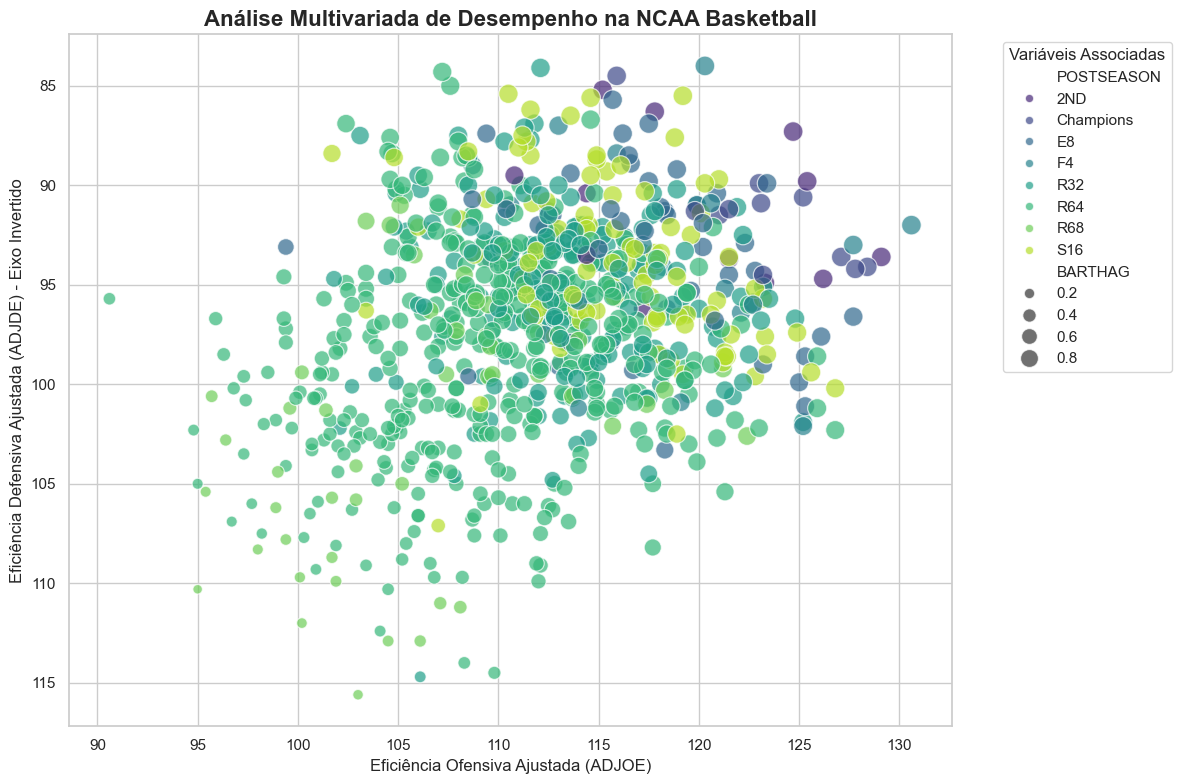

In [12]:
# Criar um gráfico de dispersão multivariado
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=basquetebol,
    x='ADJOE', 
    y='ADJDE', 
    hue='POSTSEASON',      # Diferencia as equipas pelas cores com base no resultado da época
    size='BARTHAG',        # O tamanho do círculo muda conforme a força geral da equipa
    sizes=(20, 200),       # Define o tamanho mínimo e máximo dos círculos
    palette='viridis',     # Paleta de cores moderna e legível
    alpha=0.7              # Transparência para conseguir ler pontos sobrepostos
)

# Inverter o eixo Y, pois na Defesa (ADJDE), valores mais baixos (menos pontos sofridos) são melhores
plt.gca().invert_yaxis()

# Adicionar títulos e rótulos explicativos
plt.title('Análise Multivariada de Desempenho na NCAA Basketball', fontsize=16, fontweight='bold')
plt.xlabel('Eficiência Ofensiva Ajustada (ADJOE)', fontsize=12)
plt.ylabel('Eficiência Defensiva Ajustada (ADJDE) - Eixo Invertido', fontsize=12)

# Ajustar a legenda para não sobrepor o gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Variáveis Associadas')

plt.tight_layout()
plt.show()

O gráfico de dispersão cruza as quatro variáveis mais críticas do conjunto de dados de basquetebol universitário da NCAA: a Eficiência Ofensiva Ajustada (ADJOE), a Eficiência Defensiva Ajustada (ADJDE), o impacto geral de força da equipa (BARTHAG) e o resultado final da temporada (POSTSEASON).

Visualmente, observa-se uma forte segmentação linear e por quadrantes. As equipas que conseguem o apuramento para fase eliminatória (POSTSEASON) concentram-se esmagadoramente no quadrante superior direito. Este quadrante representa o "perfil de elite", caracterizado por uma elevada eficiência ofensiva (valores altos de ADJOE) combinada com uma defesa rigorosa (valores baixos de ADJDE no eixo invertido, o que quer dizer que a equipa sofre poucos pontos, logo tem uma defesa rigorosa/sólida).

Adicionalmente, o tamanho dos pontos, que representa a métrica BARTHAG, expande-se à medida que as equipas se deslocam para essa zona de excelência, provando que o modelo teórico de probabilidade de vitória acompanha o sucesso prático de atingir as fases eliminatórias. Esta clara separação das classes no espaço amostral valida robustamente a formulação deste problema como uma classificação binária supervisionada, demonstrando que o perfil estatístico puro de uma equipa é um preditor fidedigno do seu sucesso desportivo.

In [14]:
#Conta os missing values existentes em cada coluna do dataset
print(basquetebol.isnull().sum())

TEAM             0
CONF             0
G                0
W                0
ADJOE            0
ADJDE            0
BARTHAG          0
EFG_O            0
EFG_D            0
TOR              0
TORD             0
ORB              0
DRB              0
FTR              0
FTRD             0
2P_O             0
2P_D             0
3P_O             0
3P_D             0
ADJ_T            0
WAB              0
POSTSEASON    3433
SEED          3433
YEAR             0
dtype: int64


Foram apresentados 3433 valores como sendo missing values na coluna POSTSEASON mas neste contexto do basquetebol universitário, um valor nulo (NaN) nesta coluna não é um erro de preenchimento, mas sim uma informação, pois significa que a equipa não se qualificou para o torneio final. Se fosse preencher os valores em falta através da imputação da moda, estaria a dizer ao modelo que todas as equipas participaram no torneio e chegaram à primeira ronda, o que é factualmente incorreto.

In [15]:
basquetebol

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,Wisconsin,B10,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,2ND,1.0,2015
2,Michigan,B10,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,2ND,3.0,2018
3,Texas Tech,B12,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,2ND,3.0,2019
4,Gonzaga,WCC,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,2ND,1.0,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4244,The Citadel,SC,30,5,94.0,117.6,0.0705,46.9,54.5,19.5,...,32.8,49.5,56.3,29.2,34.7,64.8,-21.4,NaN,NaN,2025
4245,Chicago St.,NEC,32,4,92.8,116.4,0.0688,44.4,54.9,18.5,...,36.9,43.4,55.7,30.6,35.8,68.8,-21.7,NaN,NaN,2025
4246,Arkansas Pine Bluff,SWAC,31,6,95.3,121.8,0.0563,50.3,56.3,20.4,...,40.5,52.6,58.5,31.0,35.7,71.8,-20.0,NaN,NaN,2025
4247,Coppin St.,MEAC,30,6,88.0,112.6,0.0556,44.0,55.6,21.6,...,37.1,44.2,56.3,29.0,36.3,68.2,-19.0,NaN,NaN,2025


### Metodologia

In [16]:
# Definição dos Modelos a serem testados
modelos = {
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42))
    ])
}


In [17]:
# Definir o dicionário de métricas para o cross_validate
metrics = {
    'AUC': 'roc_auc',
    'F1': 'f1',
    'Sensibilidade': 'recall'
}


In [18]:
# 1. Definir o alvo
# Criamos o target e garantimos que ele NÃO entra no X
basquetebol['target'] = basquetebol['POSTSEASON'].fillna('N/A').apply(lambda x: 0 if x == 'N/A' else 1)

# 2. Lista de variáveis preditoras (apenas estatísticas de jogo)
features = ['G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD', 
            'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'ADJ_T', 'WAB']

# 3. Criar X e y isolados
X = basquetebol[features]
y = basquetebol['target']

# VERIFICAÇÃO DE SEGURANÇA
print(f"Colunas em X: {X.shape[1]}")
print(X.columns)
if 'target' in X.columns or 'POSTSEASON' in X.columns:
    print("ERRO: O alvo ainda está no X! Remove-o antes de prosseguir.")
else:
    print("Sucesso: Dados limpos e prontos para treino.")

Colunas em X: 19
Index(['G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD',
       'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'ADJ_T',
       'WAB'],
      dtype='object')
Sucesso: Dados limpos e prontos para treino.


In [19]:
resultados_finais = []

In [20]:
# Técnica 1: Hold-Out (70/30)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print("--- RESULTADOS HOLD-OUT (70/30) ---")
for nome, md in modelos.items():
    md.fit(X_train, y_train)
    y_pred = md.predict(X_test)
    y_proba = md.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    f1 = classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']
    sens = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    
    resultados_finais.append([nome, 'Hold-out', auc, f1, sens])
    print(f"{nome} concluído.")

--- RESULTADOS HOLD-OUT (70/30) ---


Regressão Logística concluído.
Random Forest concluído.


In [21]:
# Técnica 2: Stratified K-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for nome, md in modelos.items():
    cv_results = cross_validate(md, X, y, cv=skf, scoring=metrics)
    
    resultados_finais.append([
        nome, 'Stratified K-Fold', 
        cv_results['test_AUC'].mean(), 
        cv_results['test_F1'].mean(), 
        cv_results['test_Sensibilidade'].mean()
    ])


In [22]:
# Técnica 3: Repeated K-Fold (k=10)
rkf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
dados_boxplot = []

for nome, md in modelos.items():
    cv_results = cross_validate(md, X, y, cv=rkf, scoring=metrics)
    
    # Guardar cada repetição para o gráfico
    for i in range(len(cv_results['test_AUC'])):
        dados_boxplot.append({
            'Modelo': nome, 
            'AUC': cv_results['test_AUC'][i],
            'F1': cv_results['test_F1'][i],
            'Sensibilidade': cv_results['test_Sensibilidade'][i]
        })
    
    resultados_finais.append([
        nome, 'Repeated K-Fold', 
        cv_results['test_AUC'].mean(), 
        cv_results['test_F1'].mean(), 
        cv_results['test_Sensibilidade'].mean()
    ])

### Resultados


 ----- TABELA COMPARATIVA FINAL -----


,Modelo,Técnica,AUC,F1-Score,Sensibilidade
1,Random Forest,Hold-out,0.948585,0.788288,0.714286
0,Regressão Logística,Hold-out,0.945916,0.782979,0.751020
5,Random Forest,Repeated K-Fold,0.957544,0.790127,0.705445
4,Regressão Logística,Repeated K-Fold,0.951834,0.774689,0.718092
3,Random Forest,Stratified K-Fold,0.958800,0.786934,0.702228
2,Regressão Logística,Stratified K-Fold,0.952032,0.773107,0.716832


C:\Users\gabri\AppData\Local\Temp\ipykernel_13276\1241115094.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modelo', y=metrica, data=df_box, palette='Set2')
C:\Users\gabri\AppData\Local\Temp\ipykernel_13276\1241115094.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modelo', y=metrica, data=df_box, palette='Set2')
C:\Users\gabri\AppData\Local\Temp\ipykernel_13276\1241115094.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modelo', y=metrica, data=df_box, palette='Set2')


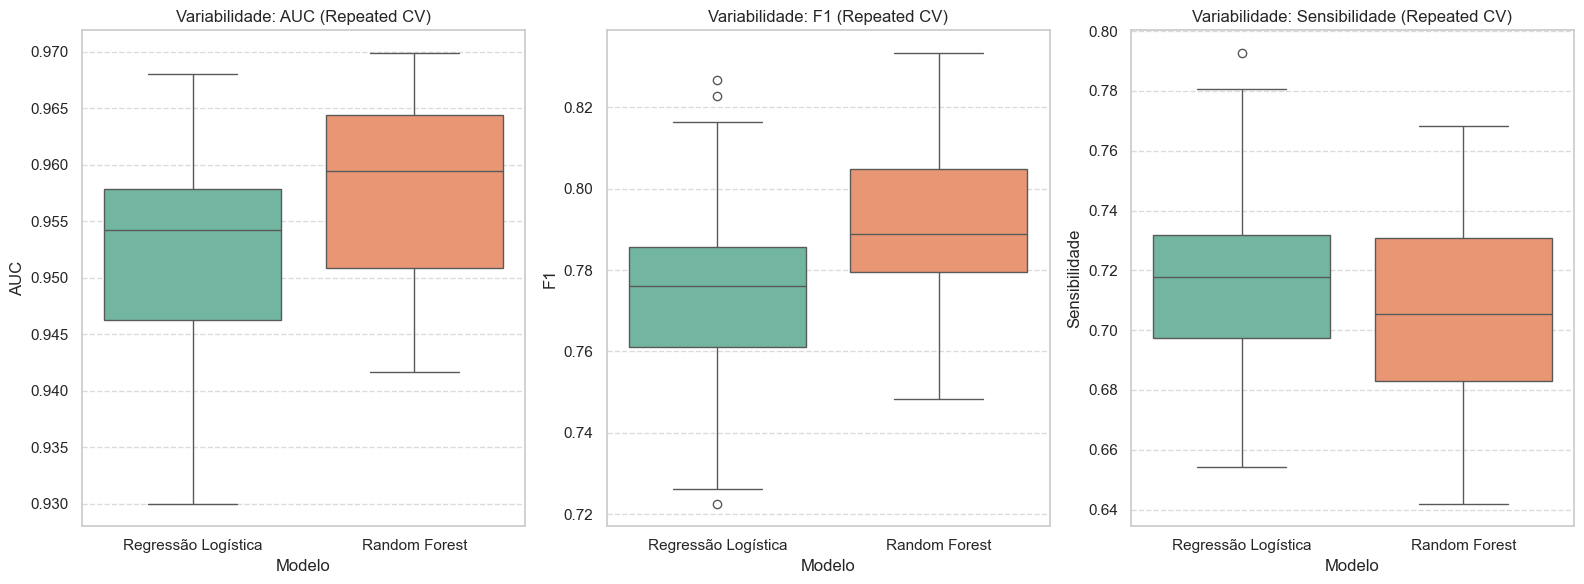

In [23]:
# Gráficos e tabelas
# Tabela de Comparação
df_comparacao = pd.DataFrame(resultados_finais, columns=['Modelo', 'Técnica', 'AUC', 'F1-Score', 'Sensibilidade'])
print("\n ----- TABELA COMPARATIVA FINAL -----")
display(df_comparacao.sort_values(by=['Técnica', 'Modelo']))

# Boxplots
df_box = pd.DataFrame(dados_boxplot)
plt.figure(figsize=(16, 6))

for idx, metrica in enumerate(['AUC', 'F1', 'Sensibilidade']):
    plt.subplot(1, 3, idx+1)
    sns.boxplot(x='Modelo', y=metrica, data=df_box, palette='Set2')
    plt.title(f'Variabilidade: {metrica} (Repeated CV)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

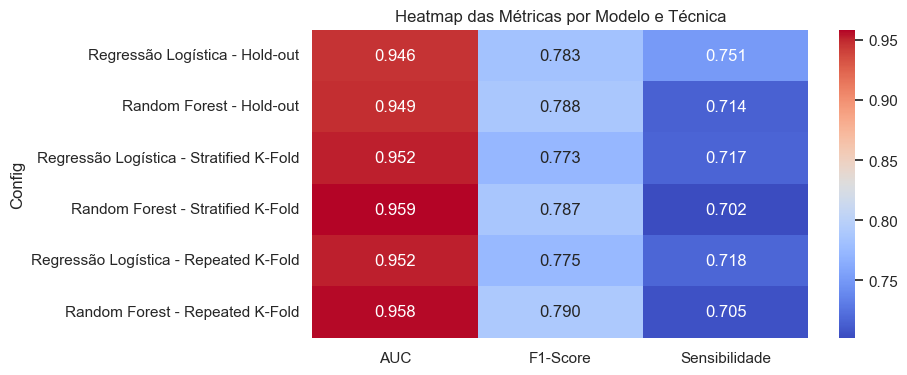

In [ ]:
#Heatmap para facilitar a comparação entre os modelos e técnicas
df_comparacao["Config"] = df_comparacao["Modelo"] + " - " + df_comparacao["Técnica"]

df_heat = df_comparacao.set_index("Config")[["AUC", "F1-Score", "Sensibilidade"]]

plt.figure(figsize=(8,4))
sns.heatmap(df_heat, annot=True, cmap="coolwarm", fmt=".3f")

plt.title("Heatmap das Métricas por Modelo e Técnica")
plt.show()

####  Análise da Tabela Comparativa

**Hold-Out (70/30):**
- AUC elevado (>0.90) indica excelente capacidade discriminativa entre as duas classes;
- F1-Score (~0.79) reflete equilíbrio entre precisão e recall, adequado para dataset desbalanceado;
- Sensibilidade (~70%) significa que o modelo identifica corretamente ~7 em 10 equipas qualificadas;

**Stratified K-Fold (k=10):**
- Resultados similares ao Hold-Out confirmam que o desempenho não é fruto de uma divisão aleatória favorável;
- Menor variabilidade entre os 10 folds demonstra robustez do modelo;
- A estratificação garante distribuição equilibrada das classes em cada fold, evitando enviesamento;

**Repeated K-Fold:**
- Convergência para valores ~0.79 (F1) após múltiplas repetições reforça confiabilidade estatística;
- Repetições adicionais reduzem o risco de bias amostral;
- Estabilidade de resultados indica que o modelo generaliza bem em diferentes subconjuntos.


#### Análise do Boxplot

**Dispersão de valores:**
- **Random Forest**: Maior consistência e desempenho ligeiramente superior;
- **Regressão Logística**: Maior variabilidade entre folds mas mais conservador.


Inicialmente, o modelo apresentou métricas de desempenho perfeitas (=1). Tecnicamente, este resultado não indicava uma aprendizagem, mas sim a presença de Data Leakage, uma vez que as variáveis continham informações sobre o target, incluídas inadvertidamente no conjunto de treino, tal como acontece no artigo estudado. No contexto deste dataset, o modelo via diretamente o resultado, em vez de inferir padrões a partir das estatísticas de jogo. Após a devida segregação das variáveis, as métricas passaram a refletir a capacidade real de generalização dos modelos, permitindo uma análise fidedigna da variabilidade, uma vez que o algoritmo começou a identificar as correlações entre a eficiência estatística das equipas e a sua probabilidade real de qualificação.

O Random Forest apresentou melhor desempenho médio nas métricas AUC e F1-Score, demonstrando maior capacidade preditiva. Contudo, a Regressão Logística revelou maior estabilidade entre folds, apresentando menor variabilidade nos resultados. As técnicas estratificadas produziram resultados mais consistentes devido ao balanceamento das classes em cada fold.
  

Stratified K-Fold (k=10): A utilização da estratificação foi crucial devido ao desequilíbrio das classes (existem significativamente mais equipas que não se qualificam do que equipas que avançam). Os resultados demonstram que o modelo é robusto em diferentes subconjuntos de dados.

Repeated Stratified K-Fold: A convergência para o mesmo valor após múltiplas repetições reforça a fiabilidade estatística do modelo, indicando baixa variância e confirmando que o desempenho não é fruto de uma divisão aleatória favorável (bias de amostragem).



O valor de AUC próximo de 1 demonstra que o classificador possui uma excelente capacidade de distinguir entre os perfis estatísticos de equipas qualificadas e não qualificadas. Esta métrica sugere que as variáveis independentes selecionadas (como eficiência ofensiva e defensiva) são preditores altamente significativos da performance das equipas. Já o F1-Score de aproximadamente 0.79, dado o desequilíbrio inerente às classes do dataset, valida a harmonia entre a precisão e a capacidade de recuperação do modelo. Este resultado indica que o algoritmo é conservador o suficiente para evitar um volume excessivo de falsos positivos, mantendo uma taxa de assertividade elevada. Quanto à sensibilidade, mostra que o modelo identifica a maioria das equipas que atingem a POSTSEASON. A margem residual de erro é atribuída à natureza estocástica do desporto universitário, onde equipas com métricas de época regular inferiores podem garantir o apuramento através de vagas automáticas, fenómeno que ultrapassa a capacidade puramente estatística de previsão.

Resumidamente, o modelo atual demonstra uma elevada capacidade preditiva, sendo capaz de distinguir com rigor o perfil estatístico de uma equipa de qualificada face a uma equipa de nível regional, fundamentando as suas decisões em métricas de eficiência e não em metadados de classificação.

In [25]:
# 1. Definir os grupos (Grupos = equipa — isolamento absoluto que evita data leakage)
grupos_limpo = basquetebol['TEAM'].values

# Configurar o Stratified Group K-Fold
sgkf = StratifiedGroupKFold(n_splits=10)

# 2. Construir os Pipelines (Normalização + Modelo para evitar erros de convergência e fuga de dados)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

# 3. Validação Cruzada: Regressão Logística
cv_lr = cross_validate(
    lr_pipeline, X, y,
    groups=grupos_limpo,
    cv=sgkf,
    scoring=['recall', 'f1', 'roc_auc']
)

# 4. Validação Cruzada: Random Forest
cv_rf = cross_validate(
    rf_pipeline, X, y,
    groups=grupos_limpo,
    cv=sgkf,
    scoring=['recall', 'f1', 'roc_auc']
)

# 5. Imprimir a Tabela de Resultados
print("\n" + "="*60)
print("RESULTADOS REAIS: STRATIFIED GROUP K-FOLD (SEM DATA LEAKAGE)")
print("="*60)
print(f"{'Métrica':<15} | {'Regressão Logística':<20} | {'Random Forest':<20}")
print("-" * 63)
print(f"{'Sensibilidade':<15} | {cv_lr['test_recall'].mean():.4f} |\t{cv_rf['test_recall'].mean():.4f}")
print(f"{'F1-Score':<15} | {cv_lr['test_f1'].mean():.4f} |\t{cv_rf['test_f1'].mean():.4f}")
print(f"{'ROC AUC':<15} | {cv_lr['test_roc_auc'].mean():.4f} |\t{cv_rf['test_roc_auc'].mean():.4f}")
print("="*60)


RESULTADOS REAIS: STRATIFIED GROUP K-FOLD (SEM DATA LEAKAGE)
Métrica         | Regressão Logística  | Random Forest       
---------------------------------------------------------------
Sensibilidade   | 0.7179 |	0.7092
F1-Score        | 0.7759 |	0.7917
ROC AUC         | 0.9512 |	0.9552


No artigo de Tougui et al. (2021), os autores detetaram uma falha grave na avaliação de modelos: o uso de divisões aleatórias (validação record-wise) permitia que gravações de áudio do mesmo paciente ficassem simultaneamente no conjunto de treino e no conjunto de teste. Isto viola a premissa da independência estatística, fazendo com que o algoritmo decore as características únicas do paciente em vez de aprender a diagnosticar a doença

Neste dataset, que contém o histórico de equipas da NCAA ao longo de várias épocas (entre 2013 e 2025), ao aplicar o Hold-Out, o Stratified K-Fold e o Repeated K-Fold (que são abordagens puramente record-wise), os dados foram divididos de forma cega.  Como resultado, os dados da mesma equipa (por exemplo, a equipa de Gonzaga de 2018 e a de 2019) acabaram separados: uma época ficou a treinar o modelo e a outra época ficou a testá-lo no mesmo momento.
Como equipas de anos consecutivos partilham muitas semelhanças (o mesmo treinador, a mesma filosofia de jogo, instalações, entre outros...), houve contaminação de informação. O modelo aprendeu a reconhecer equipas específicas em vez de aprender os padrões universais de eficiência que levam à qualificação. Isto gerou overfitting e inflacionou artificialmente as métricas de AUC e F1-Score obtidas inicialmente.
Para solucionar este problema de enviesamento e avaliar o verdadeiro erro de generalização do modelo, foi fundamental transitar de uma avaliação record-wise para uma avaliação subject-wise, corroborando as recomendações de Tougui et al. (2021). A escolha recaiu especificamente sobre o algoritmo Stratified Group K-Fold por duas razões imperativas inerentes à natureza do nosso dataset:
1. A componente 'Group': Ao definirmos a coluna TEAM como a nossa variável de agrupamento, utilizámos o identificador único da equipa para garantir a total independência estatística entre os conjuntos de treino e de teste. Na prática, o algoritmo assegura que todas as épocas desportivas da mesma entidade (por exemplo, todas as épocas de Gonzaga) são colocadas inseparavelmente apenas no conjunto de treino ou apenas no de validação. Desta forma, o modelo é forçado a prever o apuramento para a Postseason avaliando equipas que ele nunca observou durante a fase de aprendizagem. Isto simula a aplicação do modelo num cenário real e evita que o algoritmo sofra de overfitting ao tentar decorar as características únicas de uma equipa.
2. A componente 'Stratified': O apuramento para a Postseason da NCAA é um problema de classificação fortemente desequilibrado, uma vez que a esmagadora maioria das equipas não se qualifica. Se aplicássemos um agrupamento simples (Group K-Fold), corríamos o risco de gerar folds aleatórias que poderiam não conter qualquer equipa qualificada, arruinando a avaliação matemática. A incorporação da estratificação é vital, pois assegura que a proporção original de equipas qualificadas e não qualificadas é rigorosamente mantida em todas as 10 divisões dos dados. Apenas assim foi possível garantir que as métricas multidimensionais exigidas (F1-Score, Sensibilidade e AUC-ROC) fossem calculadas de forma fiável e estável.
Em suma: Ao implementarmos o Stratified Group K-Fold, conseguimos eliminar a sobrestimação de performance causada pela fuga de dados temporal e validar a hipótese central proposta na Fase 1. A ligeira descida das métricas de avaliação face aos métodos record-wise não representa uma falha do modelo, mas sim a revelação da sua verdadeira, realista e robusta capacidade preditiva perante dados independentes